In [ ]:
import pandas as pd
import numpy as np
import json

In [ ]:
instances = pd.read_json('/content/instances.jsonl', lines=True)
truth = pd.read_json("/content/truth.jsonl", lines=True)

print(instances.shape)
print(truth.shape)

(19538, 9)
(19538, 6)


In [ ]:
df = pd.merge(instances, truth, on="id")

print(df.shape)
df.head()

(19538, 14)


,postMedia,postText,id,targetCaptions,targetParagraphs,targetTitle,postTimestamp,targetKeywords,targetDescription,truthJudgments,truthMean,truthClass,truthMedian,truthMode
0,[],[UK’s response to modern slavery leaving victi...,858462320779026432,[modern-slavery-rex.jpg],[Thousands of modern slavery victims have not ...,‘Inexcusable’ failures in UK’s response to mod...,Sat Apr 29 23:25:41 +0000 2017,"modern slavery, Department For Work And Pensio...",“Inexcusable” failures in the UK’s system for ...,"[0.33333333330000003, 0.0, 0.33333333330000003...",0.133333,no-clickbait,0.000000,0.000000
1,[],[this is good],858421020331560960,"[In this July 1, 2010 file photo, Dr. Charmain...",[President Donald Trump has appointed the pro-...,Donald Trump Appoints Pro-Life Advocate as Ass...,Sat Apr 29 20:41:34 +0000 2017,"Americans United for Life, Dr. Charmaine Yoest...",President Donald Trump has appointed pro-life ...,"[1.0, 1.0, 1.0, 1.0, 1.0]",1.000000,clickbait,1.000000,1.000000
2,[],"[The ""forgotten"" Trump roast: Relive his bruta...",858368123753435136,[President Trump will not attend this year's W...,[When the White House correspondents’ dinner i...,The ‘forgotten’ Trump roast: Relive his brutal...,Sat Apr 29 17:11:23 +0000 2017,"trump whcd, whcd, white house correspondents d...",President Trump won't be at this year's White ...,"[0.33333333330000003, 1.0, 0.33333333330000003...",0.466667,no-clickbait,0.333333,0.333333
3,[],[Meet the happiest #dog in the world!],858323428260139008,"[Maru , Maru, Maru, Maru, Maru]",[Adorable is probably an understatement. This ...,"Meet The Happiest Dog In The World, Maru The H...",Sat Apr 29 14:13:46 +0000 2017,"Maru, husky, dogs, pandas, furball, instagram","The article is about Maru, a husky dog who has...","[1.0, 0.6666666666000001, 1.0, 1.0, 1.0]",0.933333,clickbait,1.000000,1.000000
4,[],[Tokyo's subway is shut down amid fears over a...,858283602626347008,[All nine lines of Tokyo's subway system were ...,[One of Tokyo's major subways systems says it ...,Tokyo's subway is shut down amid fears over an...,Sat Apr 29 11:35:31 +0000 2017,"Tokyo,subway,shut,fears,North,Korean,attack","The temporary suspension, which lasted ten min...","[0.0, 0.0, 0.0, 0.0, 0.0]",0.000000,no-clickbait,0.000000,0.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19538 entries, 0 to 19537
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   postMedia          19538 non-null  object 
 1   postText           19538 non-null  object 
 2   id                 19538 non-null  int64  
 3   targetCaptions     19538 non-null  object 
 4   targetParagraphs   19538 non-null  object 
 5   targetTitle        19538 non-null  object 
 6   postTimestamp      19538 non-null  object 
 7   targetKeywords     19538 non-null  object 
 8   targetDescription  19538 non-null  object 
 9   truthJudgments     19538 non-null  object 
 10  truthMean          19538 non-null  float64
 11  truthClass         19538 non-null  object 
 12  truthMedian        19538 non-null  float64
 13  truthMode          19538 non-null  float64
dtypes: float64(3), int64(1), object(10)
memory usage: 2.1+ MB


In [ ]:
df.isnull().sum()

,0
postMedia,0
postText,0
id,0
targetCaptions,0
targetParagraphs,0
targetTitle,0
postTimestamp,0
targetKeywords,0
targetDescription,0
truthJudgments,0


In [ ]:
df["truthClass"].value_counts()

,count
truthClass,
no-clickbait,14777
clickbait,4761


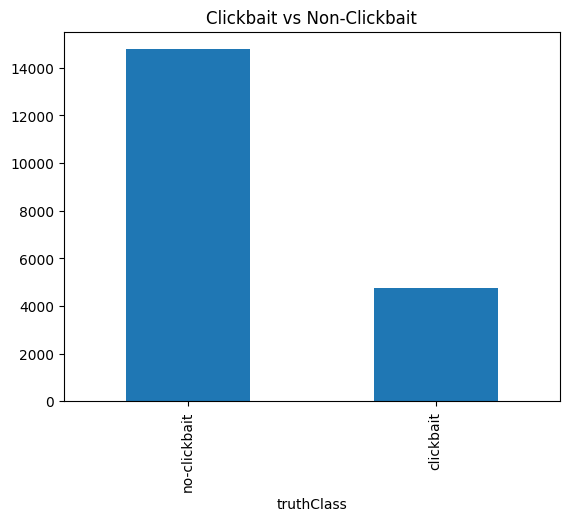

In [ ]:
import matplotlib.pyplot as plt

df["truthClass"].value_counts().plot(kind="bar")
plt.title("Clickbait vs Non-Clickbait")
plt.show()

In [ ]:
for i in range(5):
    print("Headline:", df["postText"].iloc[i])
    print("Score:", df["truthMean"].iloc[i])
    print("Class:", df["truthClass"].iloc[i])
    print("-"*60)

Headline: ['UK’s response to modern slavery leaving victims destitute while abusers go free']
Score: 0.13333333332
Class: no-clickbait
------------------------------------------------------------
Headline: ['this is good']
Score: 1.0
Class: clickbait
------------------------------------------------------------
Headline: ['The "forgotten" Trump roast: Relive his brutal 2004 thrashing at the New York Friars Club']
Score: 0.46666666663999995
Class: no-clickbait
------------------------------------------------------------
Headline: ['Meet the happiest #dog in the world!']
Score: 0.9333333333199999
Class: clickbait
------------------------------------------------------------
Headline: ["Tokyo's subway is shut down amid fears over an imminent North Korean missile attack on Japan"]
Score: 0.0
Class: no-clickbait
------------------------------------------------------------


In [ ]:
df

,postMedia,postText,id,targetCaptions,targetParagraphs,targetTitle,postTimestamp,targetKeywords,targetDescription,truthJudgments,truthMean,truthClass,truthMedian,truthMode
0,[],[UK’s response to modern slavery leaving victi...,858462320779026432,[modern-slavery-rex.jpg],[Thousands of modern slavery victims have not ...,‘Inexcusable’ failures in UK’s response to mod...,Sat Apr 29 23:25:41 +0000 2017,"modern slavery, Department For Work And Pensio...",“Inexcusable” failures in the UK’s system for ...,"[0.33333333330000003, 0.0, 0.33333333330000003...",0.133333,no-clickbait,0.000000,0.000000
1,[],[this is good],858421020331560960,"[In this July 1, 2010 file photo, Dr. Charmain...",[President Donald Trump has appointed the pro-...,Donald Trump Appoints Pro-Life Advocate as Ass...,Sat Apr 29 20:41:34 +0000 2017,"Americans United for Life, Dr. Charmaine Yoest...",President Donald Trump has appointed pro-life ...,"[1.0, 1.0, 1.0, 1.0, 1.0]",1.000000,clickbait,1.000000,1.000000
2,[],"[The ""forgotten"" Trump roast: Relive his bruta...",858368123753435136,[President Trump will not attend this year's W...,[When the White House correspondents’ dinner i...,The ‘forgotten’ Trump roast: Relive his brutal...,Sat Apr 29 17:11:23 +0000 2017,"trump whcd, whcd, white house correspondents d...",President Trump won't be at this year's White ...,"[0.33333333330000003, 1.0, 0.33333333330000003...",0.466667,no-clickbait,0.333333,0.333333
3,[],[Meet the happiest #dog in the world!],858323428260139008,"[Maru , Maru, Maru, Maru, Maru]",[Adorable is probably an understatement. This ...,"Meet The Happiest Dog In The World, Maru The H...",Sat Apr 29 14:13:46 +0000 2017,"Maru, husky, dogs, pandas, furball, instagram","The article is about Maru, a husky dog who has...","[1.0, 0.6666666666000001, 1.0, 1.0, 1.0]",0.933333,clickbait,1.000000,1.000000
4,[],[Tokyo's subway is shut down amid fears over a...,858283602626347008,[All nine lines of Tokyo's subway system were ...,[One of Tokyo's major subways systems says it ...,Tokyo's subway is shut down amid fears over an...,Sat Apr 29 11:35:31 +0000 2017,"Tokyo,subway,shut,fears,North,Korean,attack","The temporary suspension, which lasted ten min...","[0.0, 0.0, 0.0, 0.0, 0.0]",0.000000,no-clickbait,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19533,[media/photo_804240867972304896.jpg],[Brazil soccer team and pilot's final intervie...,804250183642976256,"[CNBC, msnbc, NBC NEWS, TODAY, xfinity]",[Watch Live: Joe Biden Honored on Senate Floor...,"NBC News Video See Brazil Soccer Team, Pilot’s...",Thu Dec 01 09:06:00 +0000 2016,,NBC News,"[0.33333333330000003, 0.0, 1.0, 0.666666666600...",0.400000,no-clickbait,0.333333,0.000000
19534,[],[😱😱😱😱😱😱😱😱😱😱😱😱😱😱],804156272086020096,"[Instagram/madonna, Speaker Ryan Retreats on H...",[On November 30 Politico reported that Eric Tr...,Politico Scoop: Eric Trump Killed Two Deer,Thu Dec 01 02:52:50 +0000 2016,Politico Scoop: Eric Trump Killed Two Deer,Politico Scoop: Eric Trump Killed Two Deer,"[1.0, 1.0, 1.0, 1.0, 0.0]",0.800000,clickbait,1.000000,1.000000
19535,[],[Frenchs Forest high school may have to make w...,804149798651588608,[An artist's impression of the proposed new to...,[The Forest High School on Sydney's northern b...,Frenchs Forest high school may relocate to mak...,Thu Dec 01 02:27:07 +0000 2016,"frenchs forest, northern beaches, sydney, rede...",The Forest High School on Sydney's northern be...,"[0.0, 0.0, 0.0, 0.0, 0.0]",0.000000,no-clickbait,0.000000,0.000000
19536,[media/photo_804133521023324160.jpg],[Oh Jeff… #bruh],804134698729385984,[Jeff Fisher May Think Danny Woodhead Still Pl...,[NFL coaches have a lot of information to reme...,Los Angeles Rams Jeff Fisher May Think Danny W...,Thu Dec 01 01:27:06 +0000 2016,"Humor, Football, NFL, NFC West, Los Angeles Ra...","Los Angeles Rams news, rumors, scores, schedul...","[0.0, 0.0, 0.0, 0.0, 0.6666666666000001]",0.133333,no-clickbait,0.000000,0.000000


In [ ]:
print(df.columns.tolist())

['postMedia', 'postText', 'id', 'targetCaptions', 'targetParagraphs', 'targetTitle', 'postTimestamp', 'targetKeywords', 'targetDescription', 'truthJudgments', 'truthMean', 'truthClass', 'truthMedian', 'truthMode']


In [ ]:
import re

def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [ ]:
df["postText"] = df["postText"].apply(
    lambda x: " ".join(x) if isinstance(x, list) else str(x)
)

In [ ]:
df["postText"] = df["postText"].apply(
    lambda x: " ".join(x) if isinstance(x, list) else str(x)
)

In [ ]:
def first_three_paragraphs(paragraphs):
    if isinstance(paragraphs, list):
        return " ".join(paragraphs[:3])
    return ""

df["article_context"] = df["targetParagraphs"].apply(first_three_paragraphs)

In [ ]:
columns = [
    "postText",
    "targetTitle",
    "targetDescription",
    "article_context"
]

for col in columns:
    df[col] = df[col].fillna("")
    df[col] = df[col].apply(clean_text)

In [ ]:
before_click_df = df[
    ["postText", "truthMean", "truthClass"]
].copy()

In [ ]:
before_click_df.head()

,postText,truthMean,truthClass
0,uks response to modern slavery leaving victims...,0.133333,no-clickbait
1,this is good,1.000000,clickbait
2,the forgotten trump roast relive his brutal 20...,0.466667,no-clickbait
3,meet the happiest dog in the world,0.933333,clickbait
4,tokyos subway is shut down amid fears over an ...,0.000000,no-clickbait


In [ ]:
before_click_df.to_csv(
    "before_click_dataset.csv",
    index=False
)

In [ ]:
df["combined_text"] = (
    df["postText"]
    + " "
    + df["targetTitle"]
    + " "
    + df["targetDescription"]
    + " "
    + df["article_context"]
)

In [ ]:
after_click_df = df[
    ["combined_text", "truthMean", "truthClass"]
].copy()

In [ ]:
before_click_df["label"] = (
    before_click_df["truthClass"]
    == "clickbait"
).astype(int)

after_click_df["label"] = (
    after_click_df["truthClass"]
    == "clickbait"
).astype(int)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_A, test_A = train_test_split(
    before_click_df,
    test_size=0.2,
    random_state=42,
    stratify=before_click_df["label"]
)

In [ ]:
train_B, test_B = train_test_split(
    after_click_df,
    test_size=0.2,
    random_state=42,
    stratify=after_click_df["label"]
)

In [ ]:
train_A.to_csv("train_before.csv", index=False)
test_A.to_csv("test_before.csv", index=False)

train_B.to_csv("train_after.csv", index=False)
test_B.to_csv("test_after.csv", index=False)

In [ ]:
train_df = pd.read_csv("train_before.csv")
test_df = pd.read_csv("test_before.csv")

print(train_df.shape)
print(test_df.shape)

(15630, 4)
(3908, 4)


In [ ]:
X_train = train_df["postText"]
y_train = train_df["label"]

X_test = test_df["postText"]
y_test = test_df["label"]

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)


X_train_tfidf = vectorizer.fit_transform(X_train.fillna(''))
X_test_tfidf = vectorizer.transform(X_test.fillna(''))

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(max_iter=1000)

In [ ]:
predictions = model.predict(X_test_tfidf)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, predictions))
print("Precision:", precision_score(y_test, predictions))
print("Recall   :", recall_score(y_test, predictions))
print("F1 Score :", f1_score(y_test, predictions))

Accuracy : 0.8106448311156602
Precision: 0.7137096774193549
Recall   : 0.37184873949579833
F1 Score : 0.4889502762430939


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[2814  142]
 [ 598  354]]


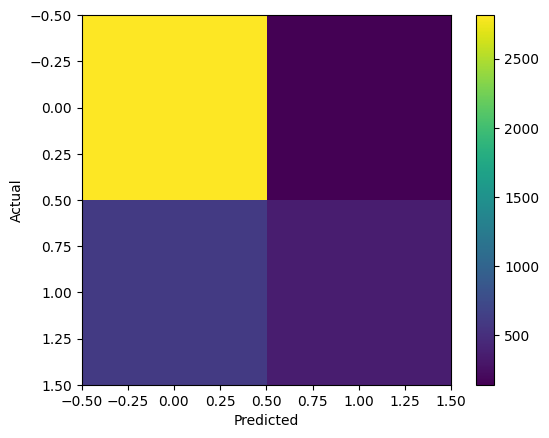

In [ ]:

plt.imshow(cm)
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
def predict_clickbait(headline):
    vector = vectorizer.transform([headline])

    prediction = model.predict(vector)[0]

    probability = model.predict_proba(vector)[0][1]

    return prediction, probability

In [ ]:
headline = "You Won't Believe What Scientists Found"

prediction, score = predict_clickbait(headline)

print("Prediction:", prediction)
print("Score:", round(score*100,2), "%")

Prediction: 1
Score: 75.75 %


In [ ]:
headline = "Government Announces New Tax Policy"

prediction, score = predict_clickbait(headline)

print("Prediction:", prediction)
print("Score:", round(score*100,2), "%")

Prediction: 0
Score: 10.74 %


In [ ]:
import joblib

joblib.dump(
    model,
    "clickbait_model.pkl"
)

joblib.dump(
    vectorizer,
    "tfidf_vectorizer.pkl"
)

['tfidf_vectorizer.pkl']

In [ ]:
from google.colab import files

files.download("clickbait_model.pkl")
files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
fp = test_df[
    (y_test == 0) &
    (predictions == 1)
]

fp[["postText"]].head(10)

,postText
0,so there is a traveling exercise class that co...
26,heres everything you should have in your car a...
49,this chinese stock soared 4500 on nasdaq and n...
144,how many christmas films have you seen
188,19 hilarious jokes about christmas guaranteed ...
252,they want nothing else
263,watch this car effortlessly drift and move sid...
295,these holiday cards are perfect gifts for the ...
341,people cant deal with this cute toddler and he...
346,this dog had the most pure reaction when he sa...


In [ ]:
fn = test_df[
    (y_test == 1) &
    (predictions == 0)
]

fn[["postText"]].head(10)

,postText
3,for all of you who have given and those of you...
8,is welldone steak a crime against beef diners ...
14,move over dubai doha is about to be the middle...
31,maybe there is something to the mediterranean ...
35,the money management business could reach a tu...
44,love and kindness
51,why investors should consider investing in water
52,the 4500 injection to stop heroin overdoses
56,perspective ive worn ash on my head on espn fo...
64,10 artists to watch in 2017 via yahoomusic


In [ ]:
after_train = pd.read_csv("train_after.csv")
after_test = pd.read_csv("test_after.csv")

In [ ]:
X_train = after_train["combined_text"]
y_train = after_train["label"]

X_test = after_test["combined_text"]
y_test = after_test["label"]

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_after = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer_after.fit_transform(X_train)
X_test_tfidf = vectorizer_after.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

after_model = LogisticRegression(
    max_iter=1000
)

after_model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(max_iter=1000)

In [ ]:
after_predictions = after_model.predict(
    X_test_tfidf
)

In [ ]:
from sklearn.metrics import *

print(
    "Accuracy:",
    accuracy_score(y_test, after_predictions)
)

print(
    "Precision:",
    precision_score(y_test, after_predictions)
)

print(
    "Recall:",
    recall_score(y_test, after_predictions)
)

print(
    "F1:",
    f1_score(y_test, after_predictions)
)

Accuracy: 0.798618219037871
Precision: 0.691415313225058
Recall: 0.3130252100840336
F1: 0.4309472161966739


In [ ]:
cm_after = confusion_matrix(
    y_test,
    after_predictions
)

print(cm_after)

[[2823  133]
 [ 654  298]]


In [ ]:
comparison = pd.DataFrame({
    "Model":[
        "Before Click",
        "After Click"
    ],
    "Accuracy":[
        "acc_before",
        "acc_after"
    ],
    "Precision":[
        "prec_before",
        "prec_after"
    ],
    "Recall":[
        "rec_before",
        "rec_after"
    ],
    "F1":[
        "f1_before",
        "f1_after"
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1
0,Before Click,acc_before,prec_before,rec_before,f1_before
1,After Click,acc_after,prec_after,rec_after,f1_after


In [ ]:
import joblib

joblib.dump(
    after_model,
    "after_click_model.pkl"
)

joblib.dump(
    vectorizer_after,
    "after_vectorizer.pkl"
)

['after_vectorizer.pkl']

In [ ]:
CLICKBAIT_PATTERNS = {

    "Curiosity Gap": [
        "you won't believe",
        "what happened next",
        "the reason why",
        "this is what",
        "guess what"
    ],

    "Emotional Trigger": [
        "shocking",
        "amazing",
        "incredible",
        "unbelievable",
        "heartbreaking"
    ],

    "Information Withholding": [
        "this one thing",
        "this secret",
        "one simple trick",
        "what happened next"
    ],

    "Exaggeration": [
        "save your life",
        "change your life",
        "best ever",
        "never before",
        "ultimate"
    ],

    "Fear Appeal": [
        "dangerous",
        "warning",
        "could kill",
        "avoid",
        "risk"
    ]
}

In [ ]:
import re

def detect_listicle(text):
    return bool(
        re.search(r"\b\d+\b", text)
    )

In [ ]:
def generate_explanation(text):

    text = text.lower()

    detected = []

    for tactic, phrases in CLICKBAIT_PATTERNS.items():

        for phrase in phrases:

            if phrase in text:
                detected.append(tactic)
                break

    if detect_listicle(text):
        detected.append("Listicle Pattern")

    return list(set(detected))

In [ ]:
headline = "You Won't Believe This One Secret That Could Save Your Life"

reasons = generate_explanation(headline)

print(reasons)

['Exaggeration', 'Curiosity Gap']


In [ ]:
def get_category(score):

    if score < 0.40:
        return "Low Clickbait"

    elif score < 0.70:
        return "Moderate Clickbait"

    else:
        return "High Clickbait"

In [ ]:
def build_response(headline,
                   probability):

    score = round(
        probability * 100,
        2
    )

    return {
        "headline": headline,
        "score": score,
        "category": get_category(probability),
        "reasons": generate_explanation(headline)
    }

In [ ]:
{
  "headline":
  "You Won't Believe This One Secret That Could Save Your Life",

  "score": 92.4,

  "category":
  "High Clickbait",

  "reasons": [
      "Curiosity Gap",
      "Information Withholding",
      "Exaggeration"
  ]
}

{'headline': "You Won't Believe This One Secret That Could Save Your Life",
 'score': 92.4,
 'category': 'High Clickbait',
 'reasons': ['Curiosity Gap', 'Information Withholding', 'Exaggeration']}

In [ ]:
import pandas as pd

test_cases = [
    {
        "Headline": "You Won't Believe What Happened Next",
        "Score": 91,
        "Reasons": "Curiosity Gap"
    },
    {
        "Headline": "10 Tricks Doctors Hate",
        "Score": 88,
        "Reasons": "Listicle Pattern"
    },
    {
        "Headline": "Government Announces New Tax Policy",
        "Score": 8,
        "Reasons": "None"
    }
]

df = pd.DataFrame(test_cases)

df.to_csv("explanation_examples.csv", index=False)

print("File saved successfully!")

File saved successfully!


In [ ]:
headline = "You Won't Believe This One Secret That Could Save Your Life"
print(generate_explanation(headline))

['Exaggeration', 'Curiosity Gap']


In [ ]:
test_headlines = [
    "You Won't Believe What Happened Next",
    "10 Tricks Doctors Hate",
    "This One Secret Could Change Your Life",
    "Government Announces New Tax Policy",
    "Warning: This Mistake Could Ruin Your Health",
    "Amazing Discovery Stuns Scientists",
    "Top 7 Ways to Save Money",
    "New Railway Project Approved by Government",
    "The Shocking Truth About Fast Food",
    "Researchers Publish New Climate Study"
]

for headline in test_headlines:
    print("Headline:", headline)
    print("Reasons:", generate_explanation(headline))
    print("-" * 50)

Headline: You Won't Believe What Happened Next
Reasons: ['Information Withholding', 'Curiosity Gap']
--------------------------------------------------
Headline: 10 Tricks Doctors Hate
Reasons: ['Listicle Pattern']
--------------------------------------------------
Headline: This One Secret Could Change Your Life
Reasons: ['Exaggeration']
--------------------------------------------------
Headline: Government Announces New Tax Policy
Reasons: []
--------------------------------------------------
Headline: Warning: This Mistake Could Ruin Your Health
Reasons: ['Fear Appeal']
--------------------------------------------------
Headline: Amazing Discovery Stuns Scientists
Reasons: ['Emotional Trigger']
--------------------------------------------------
Headline: Top 7 Ways to Save Money
Reasons: ['Listicle Pattern']
--------------------------------------------------
Headline: New Railway Project Approved by Government
Reasons: []
--------------------------------------------------
Headline:

In [ ]:
from google.colab import files

files.download("after_click_model.pkl")
files.download("after_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# New Section